In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("D:\projects\project-01-data-cleaning\data\cleaned_dataset.xlsx")
df.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,M,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,M,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,M,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,F,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         60 non-null     int64  
 1   first_name          60 non-null     object 
 2   gender              60 non-null     object 
 3   age                 60 non-null     int64  
 4   city                60 non-null     object 
 5   province            60 non-null     object 
 6   signup_date         60 non-null     object 
 7   membership_tier     60 non-null     object 
 8   purchase_count      60 non-null     int64  
 9   avg_order_value     60 non-null     float64
 10  total_spending      60 non-null     float64
 11  last_purchase_days  60 non-null     int64  
 12  payment_method      60 non-null     object 
 13  device              60 non-null     object 
 14  discount_used       60 non-null     object 
 15  returned_items      60 non-null     int64  
 16  satisfacti

In [4]:
df.describe()

,customer_id,age,purchase_count,avg_order_value,total_spending,last_purchase_days,returned_items,satisfaction_score
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,1030.500000,43.700000,17.383333,213.156500,3715.109833,198.600000,4.183333,2.983333
std,17.464249,13.946994,10.149880,130.509923,4273.901437,97.843043,2.683861,1.431979
min,1001.000000,19.000000,0.000000,27.630000,0.000000,3.000000,0.000000,1.000000
25%,1015.750000,31.750000,10.750000,108.137500,1167.035000,134.250000,2.000000,2.000000
50%,1030.500000,45.000000,17.000000,165.435000,2128.690000,203.000000,4.000000,3.000000
75%,1045.250000,58.000000,24.500000,324.107500,4692.150000,273.750000,7.000000,4.000000
max,1060.000000,65.000000,35.000000,449.810000,25000.000000,365.000000,8.000000,5.000000


In [5]:
total_customers = df['customer_id'].nunique()
total_purchases = df['purchase_count'].sum()
total_revenue = df['total_spending'].sum()
avg_spending_per_customer = df['total_spending'].mean()
avg_order_value = df['avg_order_value'].mean()
avg_satisfaction = df['satisfaction_score'].mean()
return_rate = df['returned_items'].sum() / df['purchase_count'].sum() * 100

print(f"Total customers: {total_customers}")
print(f"Total purchases: {total_purchases}")
print(f"Total revenue: {total_revenue:,.2f}")
print(f"Avg spending per customer: {avg_spending_per_customer:,.2f}")
print(f"Avg order value: {avg_order_value:,.2f}")
print(f"Avg satisfaction: {avg_satisfaction:.2f}")
print(f"Return rate: {return_rate:.1f}%")

Total customers: 60
Total purchases: 1043
Total revenue: 222,906.59
Avg spending per customer: 3,715.11
Avg order value: 213.16
Avg satisfaction: 2.98
Return rate: 24.1%


In [6]:
cityanalysis = (
            df.groupby("city")
                .agg(
                    customer = ("customer_id", "count"),
                    total_revenue = ("total_spending","sum"),
                    average_spending = ("total_spending" , "mean"),
                    total_purchases = ("purchase_count","sum"),
                    average_returns = ("returned_items","mean"),
                    satisfaction = ("satisfaction_score", "mean")
                )
                .sort_values("total_revenue",ascending=False)
)

In [7]:
cityanalysis

,customer,total_revenue,average_spending,total_purchases,average_returns,satisfaction
city,,,,,,
Mashhad,11,64118.44,5828.949091,249,2.636364,2.909091
Tabriz,12,36192.49,3016.040833,189,4.583333,3.000000
Karaj,7,26189.81,3741.401429,112,4.857143,2.857143
Ahvaz,8,23384.78,2923.097500,111,4.875000,3.500000
Isfahan,5,21975.32,4395.064000,99,4.400000,4.400000
Shiraz,6,20715.92,3452.653333,98,4.833333,2.000000
Rasht,5,15168.54,3033.708000,82,4.400000,2.600000
Tehran,6,15161.29,2526.881667,103,3.500000,2.666667


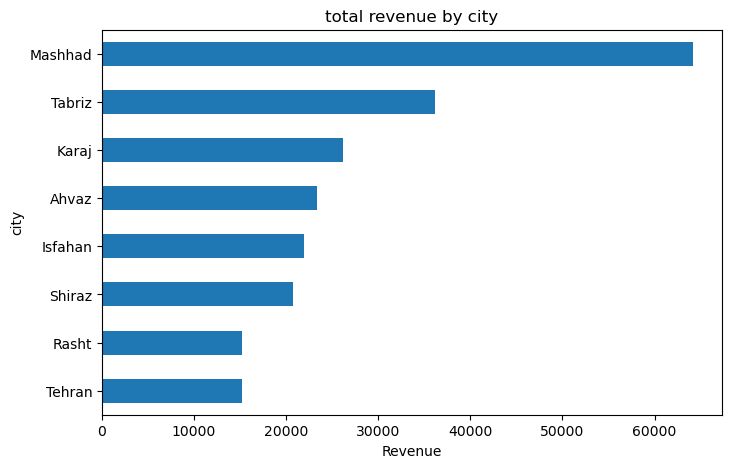

In [8]:
plt.figure(figsize = (8,5))
cityanalysis["total_revenue"].sort_values().plot(kind = "barh")
plt.title("total revenue by city")
plt.xlabel("Revenue")
plt.ylabel("city")
plt.show()

In [9]:
# Reason for Selection

# Mashhad was selected as the best city for the advertising campaign because it generated the highest total revenue and recorded the largest number of purchases. It also has one of the largest customer bases and a relatively high average spending per customer. These indicators suggest that investing in advertising in Mashhad is more likely to generate a higher return compared to the other cities.

# Risk / Limitation

# Although Mashhad has the highest revenue, its average customer satisfaction is not among the highest. Running an advertising campaign without improving the customer experience may reduce its effectiveness. In addition, this decision is based only on the available dataset. Important factors such as advertising costs, market size, customer acquisition costs, and competitors' activities are not included, which may affect the final business decision.

In [10]:
active_customers = df[df["last_purchase_days"]<=180]

In [11]:
top10 = active_customers.sort_values(
    by="total_spending",
    ascending=False
).head(10)

In [12]:
top10.head(10)

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
43,1044,Mina,F,64,Shiraz,Fars,2024-07-27,Gold,33,434.98,14354.34,165,Card,Android,No,7,2
56,1057,Maryam,F,58,Ahvaz,Khuzestan,2024-06-11,Bronze,31,436.54,13532.74,82,Cash,iPhone,No,4,4
3,1004,Sina,M,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
32,1033,Neda,F,63,Tabriz,East Azerbaijan,2021-02-25,VIP,24,230.05,5521.20,112,Card,Web,No,0,5
46,1047,Arash,M,37,Tabriz,East Azerbaijan,2024-12-18,Gold,23,220.87,5080.01,180,Online Wallet,iPhone,No,4,3
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
44,1045,Maryam,F,54,Rasht,Gilan,2022-08-07,Gold,24,161.33,3871.92,132,Cash,iPhone,No,8,1
22,1023,Ali,M,50,Mashhad,Khorasan,2024-05-02,Bronze,31,124.24,3851.44,170,Card,Web,No,2,4
13,1014,Reza,M,35,Tabriz,East Azerbaijan,2022-08-26,VIP,31,108.19,3353.89,97,Card,Android,No,5,4
16,1017,Parsa,M,49,Ahvaz,Khuzestan,2022-07-01,VIP,30,107.98,3239.40,135,Cash,iPhone,No,8,4


In [13]:
top10["Reason for Selection"] = ""

for i in top10.index:

    if top10.loc[i, "membership_tier"] in ["Gold", "Platinum"]:
        top10.loc[i, "Reason for Selection"] = "Premium member with high spending"

    else:
        top10.loc[i, "Reason for Selection"] = "High spending and active customer"

In [14]:
top10 = top10[
    [
        "customer_id",
        "first_name",
        "city",
        "membership_tier",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score",
        "Reason for Selection"
    ]
]


In [15]:
top10

,customer_id,first_name,city,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score,Reason for Selection
43,1044,Mina,Shiraz,Gold,33,14354.34,165,2,Premium member with high spending
56,1057,Maryam,Ahvaz,Bronze,31,13532.74,82,4,High spending and active customer
3,1004,Sina,Mashhad,Gold,23,6121.45,40,4,Premium member with high spending
32,1033,Neda,Tabriz,VIP,24,5521.20,112,5,High spending and active customer
46,1047,Arash,Tabriz,Gold,23,5080.01,180,3,Premium member with high spending
1,1002,Sina,Tehran,Gold,12,3917.64,3,3,Premium member with high spending
44,1045,Maryam,Rasht,Gold,24,3871.92,132,1,Premium member with high spending
22,1023,Ali,Mashhad,Bronze,31,3851.44,170,4,High spending and active customer
13,1014,Reza,Tabriz,VIP,31,3353.89,97,4,High spending and active customer
16,1017,Parsa,Ahvaz,VIP,30,3239.40,135,4,High spending and active customer


In [16]:
# Customers were selected based on two main criteria: they are still active (their last purchase was within the past 180 days) and they have spent the most money. Gold and Platinum members were considered more valuable because they have a higher membership level. Rewarding these customers can help increase customer loyalty and repeat purchases.

In [17]:
at_risk = df[
            (df["total_spending"] >= df["total_spending"].mean())&
            (df["last_purchase_days"]>180)

]

In [18]:
print("Number of At-Risk Customers:", len(at_risk))

Number of At-Risk Customers: 13


In [19]:
at_risk = at_risk[
    [
        "customer_id",
        "first_name",
        "city",
        "total_spending",
        "purchase_count",
        "last_purchase_days",
        "membership_tier"
    ]
]

at_risk

,customer_id,first_name,city,total_spending,purchase_count,last_purchase_days,membership_tier
4,1005,Kimia,Isfahan,3899.42,23,273,Silver
5,1006,Amir,Mashhad,3868.55,35,205,Gold
8,1009,Kimia,Karaj,11615.42,34,232,Silver
9,1010,Arash,Karaj,7241.47,19,276,Silver
11,1012,Arash,Mashhad,11731.50,27,224,Gold
29,1030,Sina,Mashhad,25000.00,26,340,VIP
31,1032,Neda,Isfahan,4615.05,15,243,Silver
34,1035,Arash,Tabriz,5918.21,17,365,Bronze
45,1046,Maryam,Tabriz,4923.45,15,229,VIP
49,1050,Reza,Mashhad,6198.00,30,205,Bronze


In [20]:
# Recommendation:
# Offer personalized discounts or loyalty rewards to encourage these customers to return. Sending reminder emails, exclusive offers, or limited-time promotions can help reactivate valuable customers before they are permanently lost.


# Definition:
# A customer is considered at risk if their total spending is equal to or above the average customer spending, but they have not made a purchase for more than 180 days.


# Method Used:
# Customers were filtered using two conditions: total spending greater than or equal to the average spending, and last purchase days greater than 180. Customers meeting both conditions were classified as at-risk customers.

In [21]:
df["discount_used"].value_counts()

discount_used
No     34
Yes    26
Name: count, dtype: int64

In [22]:
discount_analysis = (
        df.groupby("discount_used")
          .agg(
                customers = ("customer_id","count"),
                average_spending = ("total_spending", "mean"),
                total_purchases = ("purchase_count" , "sum"),
                satisfaction = ("satisfaction_score","mean"),
                return_rate = ("returned_items","mean")  
              
          )

    
)

In [23]:
discount_analysis

,customers,average_spending,total_purchases,satisfaction,return_rate
discount_used,,,,,
No,34,3736.741176,588,2.764706,4.264706
Yes,26,3686.822692,455,3.269231,4.076923


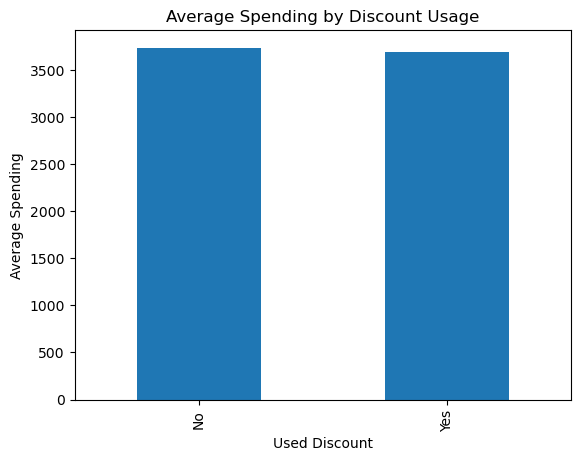

In [24]:
discount_analysis["average_spending"].plot(kind="bar")
plt.title("Average Spending by Discount Usage")
plt.xlabel("Used Discount")
plt.ylabel("Average Spending")
plt.show()

In [25]:
# Based on this dataset, we cannot conclude that discounts directly increase sales. The analysis only shows a difference between customers who used discounts and those who did not. Additional data or controlled experiments would be required to establish a causal relationship.

In [26]:
def segment_customer(row):

    if row["total_spending"] >= 6000 and row["last_purchase_days"] <= 60:
        return "Champions"

    elif row["purchase_count"] >= 10 and row["last_purchase_days"] <= 120:
        return "Loyal Customers"

    elif row["last_purchase_days"] > 180:
        return "At Risk"

    else:
        return "Needs Attention"

In [27]:
df["Customer Segment"] = df.apply(segment_customer, axis=1)

In [28]:
df["Customer Segment"].value_counts()

Customer Segment
At Risk            35
Needs Attention    15
Loyal Customers     9
Champions           1
Name: count, dtype: int64

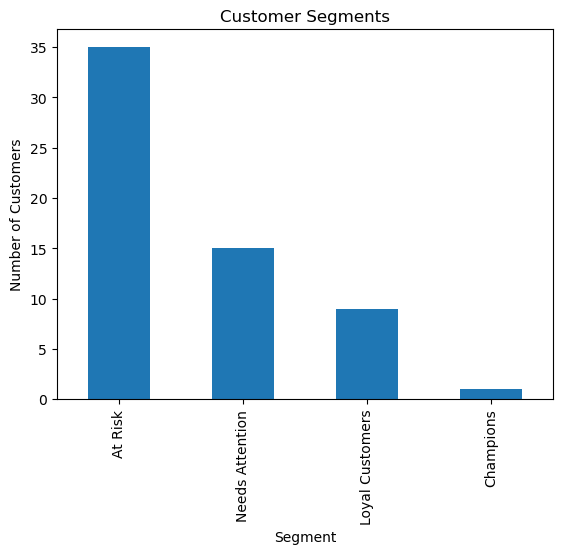

In [29]:
df["Customer Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

In [30]:
# Champions

# Customers with high spending and recent purchases. They are the company's most valuable customers and should receive exclusive rewards and VIP offers.

# Loyal Customers

# Customers who purchase frequently and consistently. The company should maintain their loyalty through personalized offers and loyalty programs.

# At Risk

# Customers who were previously valuable but have not purchased for a long time. The company should re-engage them using targeted promotions or reminder campaigns.

# Needs Attention

# Customers who are neither highly loyal nor inactive. They have the potential to become loyal customers with the right marketing strategy.

In [31]:
pareto = df.sort_values(
    by = "total_spending",
    ascending=False
    
)

In [32]:
pareto["Cumulative Revenue"] = pareto["total_spending"].cumsum()

In [33]:
pareto["Cumulative Percentage"] = (
    pareto["Cumulative Revenue"]
    / pareto["total_spending"].sum()
) * 100

In [34]:
top_20 = int(len(df) * 0.20)

In [36]:
top_20

12

In [37]:
top20_revenue = pareto.head(top_20)["total_spending"].sum()

In [40]:
percentage = (
    top20_revenue
    / df["total_spending"].sum()
) * 100

In [41]:
print(f"Top 20% customers generated {percentage:.2f}% of total revenue.")

Top 20% customers generated 54.95% of total revenue.


In [ ]:
# Result:
# The top 20% of customers generated 54.95% of the total revenue.

# Conclusion

# The Pareto principle is not strongly supported in this dataset. Although the top 20% of customers generate more than half of the total revenue, they do not account for approximately 80% of the revenue. This suggests that revenue is distributed more evenly among customers than expected under the 80/20 rule.

# Business Insight

# The company should not rely only on a small group of customers. Since a larger portion of the customer base contributes to total revenue, maintaining relationships with a wider range of customers is important for long-term business growth.

# Risk

# Because revenue is generated by a broader customer base rather than a small group of high-value customers, losing several customers across different segments could gradually reduce overall revenue. The company should focus on both retaining high-value customers and improving engagement across all customer segments.

In [42]:
df.to_excel("cleaned_customers.xlsx", index=False)
